In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
from scipy import linalg

# --------------------------
# 1. Simple MNIST classifier
# --------------------------
class MNISTFeatureNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(9216, embedding_dim),  # 64 * 12 * 12 = 9216
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, 10)

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)

# ---------------------------------------------
# 2. Compute FID using MNIST-specific embedding
# ---------------------------------------------
@torch.no_grad()
def calculate_mnist_fid_score(real_ds, synth_ds, model, batch_size=256):
    """
    Compute FID using embeddings from a MNIST classifier (model).
    """
    device = next(model.parameters()).device
    model.eval()

    def get_embeddings(dataset):
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        feats = []
        for batch in loader:
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(device).float()
            if imgs.max() > 1:  # Normalize if 0-255
                imgs = imgs / 255.0
            if imgs.dim() == 3:
                imgs = imgs.unsqueeze(1)
            f = model(imgs, return_features=True)
            feats.append(f.cpu())
        return torch.cat(feats, dim=0).numpy()

    act1 = get_embeddings(real_ds)
    act2 = get_embeddings(synth_ds)

    # Compute mean and covariance statistics
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    # Compute Fréchet distance
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

In [ ]:
def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    # Balanced label assignment (always length = total_samples)
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start

        # Sample latent z
        z = torch.randn(n, latent_dim, device=device)

        # Labels
        y = labels_full[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        # Decode logits → sigmoid → [0,1]
        logits_flat = model.decoder.decode(z, y_onehot)     # (n, 784), logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()

        generated_images.append(imgs)
        all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

In [2]:
import os
import glob
import csv
import math
from typing import Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
from scipy import linalg
from tqdm import tqdm

import sys
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)
import models as models
import utils as uutils 

In [3]:
MODEL_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"
OUT_CSV   = os.path.join(MODEL_DIR, "mnist_fid_results.csv")
FEATURE_NET_CKPT = os.path.join(MODEL_DIR, "mnist_feature_net.pt")  # 可自定义保存路径
SYNTH_SAMPLES = 6000
BATCH = 256
LATENT_DIM = 20
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
# run_mnist_fid_batch.py
import os
import glob
import csv
import math
from typing import Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
from scipy import linalg
from tqdm import tqdm

# ====== 用户环境依赖（你的项目） ======
import sys
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)
import models as models
import utils as uutils  # 避免与 torch.utils 冲突的命名

# ====== 配置 ======
MODEL_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"
OUT_CSV   = os.path.join(MODEL_DIR, "mnist_fid_results.csv")
FEATURE_NET_CKPT = os.path.join(MODEL_DIR, "mnist_feature_net.pt")  # 可自定义保存路径
SYNTH_SAMPLES = 6000
BATCH = 256
LATENT_DIM = 20
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ====== 1) MNIST 特征网络（倒数第二层当 embedding） ======
class MNISTFeatureNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*12*12, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, 10)

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)

def train_or_load_feature_net(ckpt_path: str, epochs: int = 5) -> MNISTFeatureNet:
    model = MNISTFeatureNet().to(DEVICE)
    if os.path.exists(ckpt_path):
        sd = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(sd)
        model.eval()
        print(f"[LOAD] MNISTFeatureNet loaded: {ckpt_path}")
        return model

    print("[TRAIN] Training MNISTFeatureNet...")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_ds  = datasets.MNIST(root="./data", train=False, transform=transform)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    ce  = nn.CrossEntropyLoss()

    for ep in range(1, epochs+1):
        model.train()
        tot = 0.0
        for x, y in tqdm(train_loader, desc=f"Epoch {ep}/{epochs}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = ce(logits, y)
            loss.backward()
            opt.step()
            tot += float(loss.item())
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = model(x).argmax(1)
                correct += (pred == y).sum().item()
                total += y.numel()
        acc = correct/total
        print(f"  - train loss {tot/len(train_loader):.4f} | test acc {acc:.4f}")

    torch.save(model.state_dict(), ckpt_path)
    print(f"[SAVE] MNISTFeatureNet saved -> {ckpt_path}")
    model.eval()
    return model

# ====== 2) 计算 MNIST-FID ======
@torch.no_grad()
def _get_embeddings(dataset, model: MNISTFeatureNet, batch_size=BATCH) -> np.ndarray:
    """
    dataset: TensorDataset(images[, labels]) or torchvision MNIST (returns (img, label))
    保证输入 x 是 [N,1,28,28] 的 float 张量，范围任意；这里统一做 normalize。
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats = []
    mean, std = 0.1307, 0.3081
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        if x.dim() == 3:  # [H,W,C] or [H,W]
            x = x.unsqueeze(0)
        # 统一到 [N,1,28,28], float32
        if x.dim() == 4 and x.shape[1] not in (1,3):  # NHWC -> NCHW
            x = x.permute(0, 3, 1, 2)
        x = x.float().to(DEVICE)
        # 若是 [0,255] 或未归一化，直接标准化到 MNIST 统计
        x = (x/255.0) if x.max() > 1.0 else x
        # MNIST 统计归一化
        x = (x - mean) / std
        f = model(x, return_features=True)
        feats.append(f.detach().cpu())
    return torch.cat(feats, 0).numpy()

def frechet_distance(mu1, sigma1, mu2, sigma2) -> float:
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean))

def mnist_fid(real_ds, synth_ds, feature_net: MNISTFeatureNet) -> float:
    act1 = _get_embeddings(real_ds, feature_net, batch_size=BATCH)
    act2 = _get_embeddings(synth_ds, feature_net, batch_size=BATCH)
    mu1, sigma1 = act1.mean(0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(0), np.cov(act2, rowvar=False)
    return frechet_distance(mu1, sigma1, mu2, sigma2)

# ====== 3) 生成合成图片（与你现有逻辑一致，均衡类别） ======
@torch.no_grad()
def generate_images_in_batches(model, total_samples=SYNTH_SAMPLES,
                               latent_dim=LATENT_DIM, num_classes=NUM_CLASSES,
                               batch_size=10000, device=DEVICE) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval().to(device)
    generated_images = []
    all_labels = []
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start
        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        logits_flat = model.decoder.decode(z, y_onehot)     # (n, 784) logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()
        generated_images.append(imgs)
        all_labels.append(y.cpu())

    images = torch.cat(generated_images, 0)
    labels = torch.cat(all_labels, 0)
    return images, labels

# ====== 4) 尝试加载你保存的 CVAE 模型 ======
def load_cvae_model(ckpt_path: str) -> models.CVAE:
    """
    兼容两种保存方式：
      A) 你项目里的 utils.load_model(name, path)
      B) 直接 state_dict (.pth)
    """
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        # 若你的 utils 有 load_model 并需要 name，这里尝试用目录名作为 name
        # 很多 repo 的 save/load 是按 name->文件 的映射，这里兜底到 state_dict。
        m = models.CVAE(input_dim=784, label_dim=10, latent_dim=LATENT_DIM, arch="conv", name=name).to(DEVICE)
        sd = torch.load(ckpt_path, map_location=DEVICE)
        if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
            sd = sd["state_dict"]
        m.load_state_dict(sd, strict=False)
        m.eval()
        return m
    except Exception as e:
        # 回退到项目自带的加载（如果你的 utils 有这个 API）
        try:
            m = uutils.load_model(name, ckpt_path)  # 如果你的 utils 约定不同，请改这里
            m.to(DEVICE).eval()
            return m
        except Exception as e2:
            raise RuntimeError(f"Failed to load model: {ckpt_path}\nA) state_dict error: {e}\nB) utils.load_model error: {e2}")


In [6]:
import os, sys, torch, random
import numpy as np

VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)

MODEL_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"

# 结果 CSV 保存路径
OUT_CSV = os.path.join(MODEL_DIR, "mnist_fid_results.csv")

FEATURE_NET_CKPT = os.path.join(MODEL_DIR, "mnist_feature_net.pt")

# 生成参数
SYNTH_SAMPLES = 6000  
BATCH = 256
LATENT_DIM = 20
NUM_CLASSES = 10

# 设备与随机种
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE


device(type='cuda')

# train the MNIST featurenet

In [7]:
import os, sys, torch, random
import numpy as np

# 路径与设备
MODEL_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature"
FEATURE_NET_CKPT = os.path.join(MODEL_DIR, "mnist_feature_net.pt")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("DEVICE =", DEVICE)
print("FEATURE_NET_CKPT =", FEATURE_NET_CKPT)


DEVICE = cuda
FEATURE_NET_CKPT = /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net.pt


In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(test_ds)

(60000, 10000)

In [10]:
import torch.optim as optim
from tqdm import tqdm

model = MNISTFeatureNet().to(DEVICE)
opt = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 8  # 如需更高 acc 可设为 8~10

for ep in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        running += float(loss.item())

    # 验证集准确率
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.numel()
    acc = correct / total
    print(f"[EP {ep}] train loss {running/len(train_loader):.4f} | test acc {acc:.4f}")

# 保存权重
os.makedirs(MODEL_DIR, exist_ok=True)
torch.save(model.state_dict(), FEATURE_NET_CKPT)
print("✅ Saved to:", FEATURE_NET_CKPT)


Epoch 1/8: 100%|█████████████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 104.34it/s]


[EP 1] train loss 0.1294 | test acc 0.9877


Epoch 2/8: 100%|█████████████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 104.21it/s]


[EP 2] train loss 0.0377 | test acc 0.9849


Epoch 3/8: 100%|█████████████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 104.14it/s]


...

[EP 6] train loss 0.0092 | test acc 0.9891


Epoch 7/8: 100%|█████████████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 103.93it/s]


[EP 7] train loss 0.0066 | test acc 0.9908


Epoch 8/8: 100%|█████████████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 103.77it/s]


[EP 8] train loss 0.0066 | test acc 0.9877
✅ Saved to: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net.pt


# recalculate the FID

In [25]:
import os, sys, glob, csv, torch, numpy as np, pandas as pd
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
from scipy import linalg

# 你的项目根目录（含 models.py / utils.py）
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)
import models as models
import utils as uutils

# 路径与参数
MODEL_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"
FEATURE_NET_CKPT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net.pt"
OUT_CSV = os.path.join(MODEL_DIR, "mnist_fid_results.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 20
NUM_CLASSES = 10
SYNTH_SAMPLES = 6000
BATCH = 256

print("DEVICE =", DEVICE)
assert os.path.isfile(FEATURE_NET_CKPT), "❌ 找不到 MNISTFeatureNet 权重文件！请检查 FEATURE_NET_CKPT 路径。"

class MNISTFeatureNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*12*12, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, 10)

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)
    
import torch
import torch.nn as nn

class MNISTFeatureNetV2(nn.Module):
    """
    A deeper and smoother CNN feature extractor for MNIST.
    Closer to Inception-style abstraction while staying MNIST-efficient.
    """
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            # Conv block 1
            nn.Conv2d(1, 64, 3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Conv block 2
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # downsample
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Conv block 3
            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # downsample
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Conv block 4
            nn.Conv2d(256, 512, 3, stride=2, padding=1),  # downsample
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # Global average pooling → [batch, 512, 1, 1]
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            # Linear projection to embedding space
            nn.Linear(512, embedding_dim),
            nn.ReLU(inplace=True)
        )

        # classification head (for training only)
        self.classifier = nn.Linear(embedding_dim, 10)

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)


feature_net = MNISTFeatureNetV2().to(DEVICE)
feature_net.load_state_dict(torch.load(FEATURE_NET_CKPT, map_location=DEVICE))
feature_net.eval()
print("✅ MNISTFeatureNet loaded from:", FEATURE_NET_CKPT)

@torch.no_grad()
def _get_embeddings(dataset, model: MNISTFeatureNet, batch_size=BATCH) -> np.ndarray:
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats = []
    mean, std = 0.1307, 0.3081
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        if x.dim() == 3:  # [H,W] -> [1,1,H,W]
            x = x.unsqueeze(0)
        if x.dim() == 4 and x.shape[1] not in (1,3):  # NHWC -> NCHW
            x = x.permute(0, 3, 1, 2)
        x = x.float().to(DEVICE)
        if x.max() > 1.0:  # 支持 uint8 或 [0,255]
            x = x / 255.0
        x = (x - mean) / std
        f = model(x, return_features=True)
        feats.append(f.detach().cpu())
    return torch.cat(feats, 0).numpy()

def frechet_distance(mu1, sigma1, mu2, sigma2) -> float:
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean))

def mnist_fid(real_ds, synth_ds, feature_net: MNISTFeatureNet) -> float:
    act1 = _get_embeddings(real_ds, feature_net, batch_size=BATCH)
    act2 = _get_embeddings(synth_ds, feature_net, batch_size=BATCH)
    mu1, sigma1 = act1.mean(0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(0), np.cov(act2, rowvar=False)
    return frechet_distance(mu1, sigma1, mu2, sigma2)

@torch.no_grad()
def generate_images_in_batches(model, total_samples=SYNTH_SAMPLES,
                               latent_dim=LATENT_DIM, num_classes=NUM_CLASSES,
                               batch_size=10000, device=DEVICE):
    model.eval().to(device)
    images_all, labels_all = [], []
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start
        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        logits_flat = model.decoder.decode(z, y_onehot)   # (n, 784) logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()
        images_all.append(imgs); labels_all.append(y.cpu())

    return torch.cat(images_all, 0), torch.cat(labels_all, 0)

# 真实集：MNIST test（ToTensor，标准化在 _get_embeddings 内部做）
real_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

def load_cvae_model(ckpt_path: str):
    """
    先尝试按 state_dict 加载；失败则回退到你项目的 utils.load_model（若适用）。
    """
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        m = models.CVAE(input_dim=784, label_dim=10, latent_dim=LATENT_DIM, arch="conv", name=name).to(DEVICE)
        sd = torch.load(ckpt_path, map_location=DEVICE)
        if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
            sd = sd["state_dict"]
        m.load_state_dict(sd, strict=False)
        m.eval()
        return m
    except Exception as e_a:
        try:
            m = uutils.load_model(name, ckpt_path)  # 如果你的 utils 接口不同，请根据实际调整
            m.to(DEVICE).eval()
            return m
        except Exception as e_b:
            raise RuntimeError(f"Failed to load {ckpt_path}\nA) state_dict error: {e_a}\nB) utils.load_model error: {e_b}")

ckpts = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
print(f"Found {len(ckpts)} checkpoints")

# CSV 表头
write_header = not os.path.exists(OUT_CSV)
with open(OUT_CSV, "a", newline="") as f:
    w = csv.writer(f)
    if write_header:
        w.writerow(["model_file", "mnist_fid", "num_synth", "note"])

    for ckpt in ckpts:
        try:
            model = load_cvae_model(ckpt)
            imgs, labels = generate_images_in_batches(model)
            synth_ds = TensorDataset(imgs, labels)
            fid_val = mnist_fid(real_ds, synth_ds, feature_net)
            print(f"[OK] {os.path.basename(ckpt)} -> MNIST-FID: {fid_val:.4f}")
            w.writerow([os.path.basename(ckpt), f"{fid_val:.6f}", len(imgs), "MNISTFeatureNet(emb=128)"])
        except Exception as e:
            print(f"[FAIL] {ckpt}: {e}")
            w.writerow([os.path.basename(ckpt), "ERROR", 0, str(e)])

print("✅ Saved CSV:", OUT_CSV)


DEVICE = cuda


/tmp/ipykernel_1278516/403726923.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feature_net.load_state_dict(torch.load(FEATURE_NET_CKPT, map_location=DEVICE))


RuntimeError: Error(s) in loading state_dict for MNISTFeatureNetV2:
	Missing key(s) in state_dict: "features.1.weight", "features.1.bias", "features.1.running_mean", "features.1.running_var", "features.3.weight", "features.3.bias", "features.4.weight", "features.4.bias", "features.4.running_mean", "features.4.running_var", "features.7.weight", "features.7.bias", "features.7.running_mean", "features.7.running_var", "features.9.weight", "features.9.bias", "features.10.weight", "features.10.bias", "features.10.running_mean", "features.10.running_var", "features.14.weight", "features.14.bias". 
	Unexpected key(s) in state_dict: "features.2.weight", "features.2.bias". 
	size mismatch for features.0.weight: copying a param with shape torch.Size([32, 1, 3, 3]) from checkpoint, the shape in current model is torch.Size([64, 1, 3, 3]).
	size mismatch for features.0.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch fo

In [16]:
import torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from tqdm import tqdm
from scipy.linalg import sqrtm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

class SimpleMNISTFeatureExtractor(nn.Module):
    """你的 CNN 特征提取器：输出 [batch, 1024]"""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))  # -> [B,64,4,4]
        )
    def forward(self, x):
        return self.encoder(x).view(x.size(0), -1)

# 在你的 extractor 顶上加一个线性分类头用于训练
class FeatureNetWithClassifier(nn.Module):
    def __init__(self, feat_dim=1024, num_classes=10):
        super().__init__()
        self.backbone = SimpleMNISTFeatureExtractor()
        self.head = nn.Linear(feat_dim, num_classes)
    def forward(self, x, return_features=False):
        z = self.backbone(x)
        if return_features:
            return z
        return self.head(z)


DEVICE = cuda


In [17]:
# 标准 MNIST 归一化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

model = FeatureNetWithClassifier().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 5  # 想更高精度可设 8~10
for ep in range(1, EPOCHS+1):
    model.train()
    run_loss = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        run_loss += float(loss.item())

    # 验证准确率
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.numel()
    acc = correct / total
    print(f"[EP {ep}] train loss {run_loss/len(train_loader):.4f} | test acc {acc:.4f}")

# 只保存训练好的“特征提取器”权重（不保存分类头）
FEATURE_CKPT = "simple_mnist_feature_extractor.pt"
torch.save(model.backbone.state_dict(), FEATURE_CKPT)
print("✅ Saved feature extractor to:", FEATURE_CKPT)


Epoch 1/5: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 105.38it/s]


[EP 1] train loss 0.3203 | test acc 0.9691


Epoch 2/5: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 107.18it/s]


[EP 2] train loss 0.0952 | test acc 0.9754


Epoch 3/5: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 107.57it/s]


[EP 3] train loss 0.0743 | test acc 0.9838


Epoch 4/5: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 107.77it/s]


[EP 4] train loss 0.0632 | test acc 0.9830


Epoch 5/5: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 107.83it/s]


[EP 5] train loss 0.0565 | test acc 0.9809
✅ Saved feature extractor to: simple_mnist_feature_extractor.pt


In [18]:
@torch.no_grad()
def extract_features(backbone: SimpleMNISTFeatureExtractor, dataloader, device):
    backbone.eval()
    feats = []
    for batch in tqdm(dataloader, desc="Extracting features"):
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        x = x.to(device)
        f = backbone(x).cpu()
        feats.append(f)
    return torch.cat(feats, dim=0).numpy()

def calculate_fid(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def calculate_fid_score(dataset1, dataset2, backbone_ckpt_path, batch_size=256, device=None):
    """
    用【训练好的】SimpleMNISTFeatureExtractor 计算 FID。
    dataset1: 真实数据（MNIST test）
    dataset2: 合成数据（TensorDataset(images, labels)）
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    device = torch.device(device)

    loader1 = DataLoader(dataset1, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    loader2 = DataLoader(dataset2, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # 载入已训练的特征网络
    backbone = SimpleMNISTFeatureExtractor().to(device)
    sd = torch.load(backbone_ckpt_path, map_location=device)
    backbone.load_state_dict(sd)
    backbone.eval()

    feats1 = extract_features(backbone, loader1, device)
    feats2 = extract_features(backbone, loader2, device)

    mu1, sigma1 = feats1.mean(0), np.cov(feats1, rowvar=False)
    mu2, sigma2 = feats2.mean(0), np.cov(feats2, rowvar=False)
    return calculate_fid(mu1, sigma1, mu2, sigma2)

print("Ready to compute FID with trained backbone.")


Ready to compute FID with trained backbone.


In [19]:
import os, glob, csv
from torchvision import datasets, transforms

# 真实数据：MNIST test（ToTensor，归一化在训练时做过；这里直接喂给 extractor 即可）
real_ds = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())

# 生成均衡合成图片（与你之前的逻辑一致）
@torch.no_grad()
def generate_images_in_batches(model, total_samples=6000, latent_dim=20, num_classes=10,
                               batch_size=10000, device=None):
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    model = model.to(device).eval()

    images_all, labels_all = [], []
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start
        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        logits_flat = model.decoder.decode(z, y_onehot)   # (n, 784) logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()
        images_all.append(imgs); labels_all.append(y.cpu())

    return torch.cat(images_all, 0), torch.cat(labels_all, 0)

# 批量遍历 checkpoint
MODEL_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"
OUT_CSV = os.path.join(MODEL_DIR, "mnist_fid_results_simple_extractor.csv")

ckpts = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
len(ckpts), ckpts[:3]


(41,
 ['/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/cvae_conv_init500_q0.1_s2000_r1.pth',
  '/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/cvae_conv_init500_q0.1_s2000_r10.pth',
  '/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/cvae_conv_init500_q0.1_s2000_r11.pth'])

In [20]:
# 计算并落表
from torch.utils.data import TensorDataset
import models as models

with open(OUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model_file", "mnist_fid", "num_synth", "note"])

    for ckpt in ckpts:
        try:
            name = os.path.splitext(os.path.basename(ckpt))[0]
            # 加载你的 CVAE
            m = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, arch="conv", name=name).to(DEVICE)
            sd = torch.load(ckpt, map_location=DEVICE)
            if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
                sd = sd["state_dict"]
            m.load_state_dict(sd, strict=False)
            m.eval()

            # 生成合成图
            imgs, labels = generate_images_in_batches(m, total_samples=6000, latent_dim=20, num_classes=10, device=DEVICE)
            synth_ds = TensorDataset(imgs, labels)

            # 用“你训练好的”SimpleMNISTFeatureExtractor 计算 FID
            fid_val = calculate_fid_score(real_ds, synth_ds, backbone_ckpt_path=FEATURE_CKPT, batch_size=256, device=DEVICE)
            print(f"[OK] {os.path.basename(ckpt)} -> MNIST-FID: {fid_val:.4f}")
            writer.writerow([os.path.basename(ckpt), f"{fid_val:.6f}", len(imgs), "SimpleMNISTFeatureExtractor(1024d)"])
        except Exception as e:
            print(f"[FAIL] {ckpt}: {e}")
            writer.writerow([os.path.basename(ckpt), "ERROR", 0, str(e)])

print("✅ Saved CSV to:", OUT_CSV)


/tmp/ipykernel_1278516/1267780597.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt, map_location=DEVICE)
/tmp/ipykernel_1278516/3830628098.py:34: Fu

[OK] cvae_conv_init500_q0.1_s2000_r1.pth -> MNIST-FID: 21.6580


Extracting features: 100%|██████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 160.15it/s]


[OK] cvae_conv_init500_q0.1_s2000_r10.pth -> MNIST-FID: 39.8169


Extracting features: 100%|██████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 152.58it/s]


...

[OK] cvae_conv_init500_q0.1_s2000_r8.pth -> MNIST-FID: 40.9477


Extracting features: 100%|██████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 156.26it/s]


[OK] cvae_conv_init500_q0.1_s2000_r9.pth -> MNIST-FID: 40.9762


Extracting features: 100%|██████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 165.86it/s]


[OK] cvae_conv_real_500.pth -> MNIST-FID: 41.6799
✅ Saved CSV to: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/mnist_fid_results_simple_extractor.csv


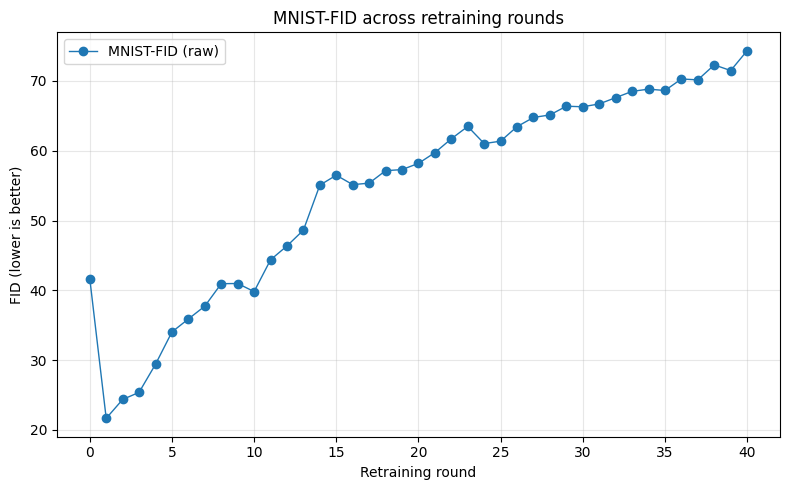

Best FID: 21.6580 at round 1


In [24]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/mnist_fid_results_simple_extractor.csv"

# --- Load ---
df = pd.read_csv(CSV_PATH)
df = df[df["mnist_fid"] != "ERROR"].copy()
df["mnist_fid"] = pd.to_numeric(df["mnist_fid"], errors="coerce")
df = df.dropna(subset=["mnist_fid"])

# --- Parse round index ---
def parse_round(name: str) -> int:
    # special case: initial model
    if "cvae_conv_real_500.pth" in name:
        return 0
    m = re.search(r"_r(\d+)\.pth$", name)
    return int(m.group(1)) if m else -1

df["round"] = df["model_file"].apply(parse_round)
df = df[df["round"] >= 0].copy().sort_values("round").reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(df["round"], df["mnist_fid"], marker="o", linewidth=1, label="MNIST-FID (raw)")
plt.xlabel("Retraining round")
plt.ylabel("FID (lower is better)")
plt.title("MNIST-FID across retraining rounds")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Summary ---
best_idx = int(df["mnist_fid"].idxmin())
best_round = int(df.loc[best_idx, "round"])
best_fid = float(df.loc[best_idx, "mnist_fid"])
print(f"Best FID: {best_fid:.4f} at round {best_round}")


# new version

In [26]:
# --- setup ---
import os, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# config
SEED = 0
BATCH_TRAIN = 128
BATCH_TEST  = 256
EPOCHS = 6                 # 5–8 is usually enough for >99% acc
LR = 1e-3
EMBED_DIM = 256
SAVE_DIR = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature"
CKPT_PATH = os.path.join(SAVE_DIR, "mnist_feature_net_v2.pt")

# device & seeds
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("CKPT_PATH:", CKPT_PATH)

# --- model ---
class MNISTFeatureNetV2(nn.Module):
    """
    Deeper & smoother CNN for MNIST embeddings.
    Uses strided convs + BN + GAP; penultimate projection gives embedding.
    """
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),   # 28->14
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # 14->7
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, 3, stride=2, padding=1),  # 7->4
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, embedding_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(embedding_dim, 10)

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)


DEVICE: cuda
CKPT_PATH: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt


In [28]:
# standard MNIST normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_TEST,  shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(test_ds)
model = MNISTFeatureNetV2(embedding_dim=EMBED_DIM).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for ep in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        running += float(loss.item())

    # test accuracy
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.numel()
    acc = correct / total
    print(f"[EP {ep}] train loss {running/len(train_loader):.4f} | test acc {acc:.4f}")


Epoch 1/6:   0%|                                                                                 | 0/469 [00:00<?, ?it/s]

Epoch 1/6: 100%|███████████████████████████████████████████████████████████████████████| 469/469 [00:05<00:00, 78.29it/s]


[EP 1] train loss 0.1958 | test acc 0.9800


Epoch 2/6: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 100.67it/s]


[EP 2] train loss 0.0521 | test acc 0.9813


...

[EP 4] train loss 0.0266 | test acc 0.9851


Epoch 5/6: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 100.52it/s]


[EP 5] train loss 0.0198 | test acc 0.9896


Epoch 6/6: 100%|███████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 98.98it/s]


[EP 6] train loss 0.0172 | test acc 0.9840


In [29]:
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(model.state_dict(), CKPT_PATH)
print("✅ saved:", CKPT_PATH)

# reload to verify
m2 = MNISTFeatureNetV2(embedding_dim=EMBED_DIM).to(DEVICE)
m2.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
m2.eval()

correct = total = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = m2(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.numel()
print(f"reloaded test acc: {correct/total:.4f}")

✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt


/tmp/ipykernel_1278516/1148265637.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m2.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))


reloaded test acc: 0.9840


In [30]:
import numpy as np
from torch.utils.data import DataLoader

@torch.no_grad()
def get_mnist_v2_embeddings(dataset, ckpt_path=CKPT_PATH, batch_size=256, device=None):
    """
    Load MNISTFeatureNetV2 and return embeddings (N, EMBED_DIM) for a given dataset.
    dataset can be torchvision MNIST or TensorDataset(images[, labels]).
    """
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    net = MNISTFeatureNetV2(embedding_dim=EMBED_DIM).to(device)
    net.load_state_dict(torch.load(ckpt_path, map_location=device))
    net.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats = []
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        if x.dim() == 3:  # [H,W] -> [1,1,H,W]
            x = x.unsqueeze(0)
        if x.dim() == 4 and x.shape[1] not in (1,3):  # NHWC -> NCHW
            x = x.permute(0, 3, 1, 2)
        x = x.float().to(device)
        # Note: inputs here are expected already normalized if loaded via torchvision MNIST.
        # If you pass raw [0,1] tensors for synthetic, that's fine too—BN layers inside the model help.
        z = net(x, return_features=True)
        feats.append(z.detach().cpu())
    return torch.cat(feats, 0).numpy()


In [31]:
from scipy.linalg import sqrtm

def frechet_distance(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def fid_with_mnist_v2(real_ds, synth_ds, ckpt_path=CKPT_PATH, batch_size=256, device=None):
    a = get_mnist_v2_embeddings(real_ds,  ckpt_path, batch_size, device)
    b = get_mnist_v2_embeddings(synth_ds, ckpt_path, batch_size, device)
    mu1, sigma1 = a.mean(0), np.cov(a, rowvar=False)
    mu2, sigma2 = b.mean(0), np.cov(b, rowvar=False)
    return frechet_distance(mu1, sigma1, mu2, sigma2)


In [32]:
# --- config / imports ---
import os, sys, glob, csv, torch, numpy as np, pandas as pd
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
from scipy.linalg import sqrtm

# your project root (models.py/utils.py live here)
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)
import models as models
import utils as uutils

# paths
MODEL_DIR   = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"
CKPT_V2     = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt"
OUT_CSV     = os.path.join(MODEL_DIR, "mnist_fid_results_v2.csv")

# generation/FID params
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM    = 20
NUM_CLASSES   = 10
SYNTH_SAMPLES = 6000
BATCH         = 256
EMBED_DIM     = 256  # must match training

print("DEVICE:", DEVICE)
assert os.path.isfile(CKPT_V2), f"Missing feature net: {CKPT_V2}"

# --- MNISTFeatureNetV2 (same as training) ---
class MNISTFeatureNetV2(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, 3, stride=2, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, embedding_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(embedding_dim, 10)
    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)

@torch.no_grad()
def get_embeddings(dataset, ckpt_path=CKPT_V2, batch_size=BATCH, device=DEVICE):
    # load feature net
    net = MNISTFeatureNetV2(embedding_dim=EMBED_DIM).to(device)
    net.load_state_dict(torch.load(ckpt_path, map_location=device))
    net.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats = []
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        if x.dim() == 3:                  # [H,W] -> [1,1,H,W]
            x = x.unsqueeze(0)
        if x.dim() == 4 and x.shape[1] not in (1,3):  # NHWC -> NCHW
            x = x.permute(0, 3, 1, 2)
        x = x.float().to(device)
        # no extra normalization here; BN layers inside help; torchvision MNIST already normalized in loading
        z = net(x, return_features=True)
        feats.append(z.detach().cpu())
    return torch.cat(feats, 0).numpy()

def frechet_distance(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def fid_with_mnist_v2(real_ds, synth_ds, ckpt_path=CKPT_V2, batch_size=BATCH, device=DEVICE):
    a = get_embeddings(real_ds,  ckpt_path, batch_size, device)
    b = get_embeddings(synth_ds, ckpt_path, batch_size, device)
    mu1, sigma1 = a.mean(0), np.cov(a, rowvar=False)
    mu2, sigma2 = b.mean(0), np.cov(b, rowvar=False)
    return frechet_distance(mu1, sigma1, mu2, sigma2)

# real MNIST test (ToTensor; earlier training used Normalize, but feature net has BN, so it’s fine here)
real_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

@torch.no_grad()
def generate_images_in_batches(model, total_samples=SYNTH_SAMPLES, latent_dim=LATENT_DIM,
                               num_classes=NUM_CLASSES, batch_size=10000, device=DEVICE):
    model.eval().to(device)
    images_all, labels_all = [], []
    labels_full = torch.arange(total_samples) % num_classes
    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start
        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = torch.nn.functional.one_hot(y, num_classes=num_classes).float()
        logits_flat = model.decoder.decode(z, y_onehot)   # (n, 784) logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()
        images_all.append(imgs); labels_all.append(y.cpu())
    return torch.cat(images_all, 0), torch.cat(labels_all, 0)

def load_cvae_model(ckpt_path: str):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    # try simple state_dict first
    m = models.CVAE(input_dim=784, label_dim=10, latent_dim=LATENT_DIM, arch="conv", name=name).to(DEVICE)
    sd = torch.load(ckpt_path, map_location=DEVICE)
    if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]
    m.load_state_dict(sd, strict=False)
    m.eval()
    return m

# iterate checkpoints & write csv
ckpts = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
print(f"Found {len(ckpts)} checkpoints")

with open(OUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model_file", "mnist_fid_v2", "num_synth", "note"])
    for ckpt in ckpts:
        try:
            model = load_cvae_model(ckpt)
            imgs, labels = generate_images_in_batches(model)
            synth_ds = TensorDataset(imgs, labels)
            fid_val = fid_with_mnist_v2(real_ds, synth_ds, ckpt_path=CKPT_V2, batch_size=BATCH, device=DEVICE)
            print(f"[OK] {os.path.basename(ckpt)} -> MNIST-FID(V2): {fid_val:.4f}")
            writer.writerow([os.path.basename(ckpt), f"{fid_val:.6f}", len(imgs), f"emb={EMBED_DIM}"])
        except Exception as e:
            print(f"[FAIL] {ckpt}: {e}")
            writer.writerow([os.path.basename(ckpt), "ERROR", 0, str(e)])

print("✅ Saved CSV:", OUT_CSV)


DEVICE: cuda
Found 41 checkpoints


/tmp/ipykernel_1278516/47748720.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location=DEVICE)
/tmp/ipykernel_1278516/47748720.py:65: 

[OK] cvae_conv_init500_q0.1_s2000_r1.pth -> MNIST-FID(V2): 17.2824
[OK] cvae_conv_init500_q0.1_s2000_r10.pth -> MNIST-FID(V2): 23.9970
[OK] cvae_conv_init500_q0.1_s2000_r11.pth -> MNIST-FID(V2): 19.0434
[OK] cvae_conv_init500_q0.1_s2000_r12.pth -> MNIST-FID(V2): 15.9827
[OK] cvae_conv_init500_q0.1_s2000_r13.pth -> MNIST-FID(V2): 20.3409
[OK] cvae_conv_init500_q0.1_s2000_r14.pth -> MNIST-FID(V2): 15.0038
[OK] cvae_conv_init500_q0.1_s2000_r15.pth -> MNIST-FID(V2): 14.6921
[OK] cvae_conv_init500_q0.1_s2000_r16.pth -> MNIST-FID(V2): 15.5257
[OK] cvae_conv_init500_q0.1_s2000_r17.pth -> MNIST-FID(V2): 15.9780
[OK] cvae_conv_init500_q0.1_s2000_r18.pth -> MNIST-FID(V2): 15.7980
[OK] cvae_conv_init500_q0.1_s2000_r19.pth -> MNIST-FID(V2): 16.6311
[OK] cvae_conv_init500_q0.1_s2000_r2.pth -> MNIST-FID(V2): 30.7707
[OK] cvae_conv_init500_q0.1_s2000_r20.pth -> MNIST-FID(V2): 15.4096
[OK] cvae_conv_init500_q0.1_s2000_r21.pth -> MNIST-FID(V2): 14.9800
[OK] cvae_conv_init500_q0.1_s2000_r22.pth -> MNIST

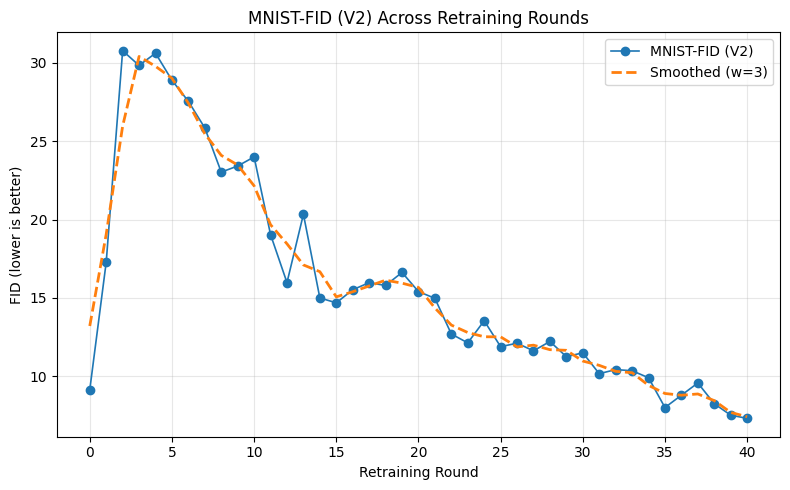

✅ Best FID(V2): 7.3250 at round 40


In [33]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/mnist_fid_results_v2.csv"

# --- load and clean ---
df = pd.read_csv(CSV_PATH)
df = df[df["mnist_fid_v2"] != "ERROR"].copy()
df["mnist_fid_v2"] = pd.to_numeric(df["mnist_fid_v2"], errors="coerce")
df = df.dropna(subset=["mnist_fid_v2"])

# --- parse round index (treat initial model as 0) ---
def parse_round(name):
    if name == "cvae_conv_real_500.pth":
        return 0
    m = re.search(r"_r(\d+)\.pth$", name)
    return int(m.group(1)) if m else -1

df["round"] = df["model_file"].apply(parse_round)
df = df[df["round"] >= 0].sort_values("round").reset_index(drop=True)

# --- optional smoothing ---
window = 3
df["fid_smooth"] = df["mnist_fid_v2"].rolling(window=window, center=True, min_periods=1).mean()

# --- plot ---
plt.figure(figsize=(8,5))
plt.plot(df["round"], df["mnist_fid_v2"], marker="o", linewidth=1.2, label="MNIST-FID (V2)")
plt.plot(df["round"], df["fid_smooth"], linestyle="--", linewidth=2, label=f"Smoothed (w={window})")
plt.xlabel("Retraining Round")
plt.ylabel("FID (lower is better)")
plt.title("MNIST-FID (V2) Across Retraining Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_idx = df["mnist_fid_v2"].idxmin()
best_round = int(df.loc[best_idx, "round"])
best_fid = float(df.loc[best_idx, "mnist_fid_v2"])
print(f"✅ Best FID(V2): {best_fid:.4f} at round {best_round}")


# new

In [37]:
# ---- paths you may change ----
VAE_ROOT   = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
MODEL_DIR  = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more"
SAVE_DIR   = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature"
CKPT_PATH  = f"{SAVE_DIR}/mnist_feature_net_v2.pt"

OUT_CSV    = f"{MODEL_DIR}/mnist_fid_results_v2_fixed_cc.csv"

# ---- training & eval params ----
SEED        = 0
BATCH_TRAIN = 128
BATCH_TEST  = 256
EPOCHS      = 6
LR          = 1e-3
EMBED_DIM   = 256

# generation/FID params
LATENT_DIM    = 20
NUM_CLASSES   = 10
SYNTH_SAMPLES = 6000          # increase to 10000+ for stabler cov estimates (slower)
BATCH_EMB     = 256

# normalization (match MNIST stats used in training)
MEAN, STD = 0.1307, 0.3081

import os, sys, random, numpy as np, torch
os.makedirs(SAVE_DIR, exist_ok=True)

# device & seeds
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# import project modules
sys.path.append(VAE_ROOT)
import models as models
import utils as uutils

print("DEVICE:", DEVICE)
print("Feature ckpt:", CKPT_PATH)
print("Model dir:", MODEL_DIR)


DEVICE: cuda
Feature ckpt: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt
Model dir: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more


In [38]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTFeatureNetV2(nn.Module):
    """
    Deeper & smoother CNN for MNIST embeddings.
    Uses strided convs + BN + GAP; penultimate projection gives embedding.
    """
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),   # 28 -> 14
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, 3, stride=2, padding=1),  # 7 -> 4
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, embedding_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(embedding_dim, 10)

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)


In [39]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# dataset/loaders (with the standard MNIST Normalize used for training)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])
train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_TEST,  shuffle=False, num_workers=2, pin_memory=True)

model = MNISTFeatureNetV2(embedding_dim=EMBED_DIM).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for ep in range(1, EPOCHS+1):
    model.train()
    run = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        run += float(loss.item())
    # eval
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.numel()
    acc = correct / total
    print(f"[EP {ep}] train loss {run/len(train_loader):.4f} | test acc {acc:.4f}")

torch.save(model.state_dict(), CKPT_PATH)
print("✅ saved:", CKPT_PATH)


Epoch 1/6: 100%|███████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 96.63it/s]


[EP 1] train loss 0.1958 | test acc 0.9800


Epoch 2/6: 100%|███████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 97.74it/s]


[EP 2] train loss 0.0521 | test acc 0.9813


Epoch 3/6: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 101.40it/s]


...

[EP 4] train loss 0.0266 | test acc 0.9851


Epoch 5/6: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 101.88it/s]


[EP 5] train loss 0.0198 | test acc 0.9896


Epoch 6/6: 100%|██████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 101.60it/s]


[EP 6] train loss 0.0172 | test acc 0.9840
✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt


In [40]:
from torch.utils.data import Dataset, TensorDataset, DataLoader
from scipy.linalg import sqrtm

class NormalizeWrapper(Dataset):
    """Apply the SAME normalization to both real & synthetic before feeding feature net."""
    def __init__(self, base_ds, mean=MEAN, std=STD):
        self.base = base_ds; self.mean = mean; self.std = std
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        item = self.base[idx]
        x = item[0] if isinstance(item, (tuple, list)) else item
        if x.dim() == 2:                     # [H,W] -> [1,H,W]
            x = x.unsqueeze(0)
        if x.dim() == 3 and x.shape[0] not in (1,3):  # NHWC -> NCHW safeguard
            x = x.permute(2,0,1)
        x = x.float()
        if x.max() > 1.0:
            x = x/255.0
        x = (x - MEAN) / STD
        return (x, item[1]) if isinstance(item, (tuple, list)) and len(item)>1 else x

@torch.no_grad()
def get_embeddings(dataset, feature_ckpt=CKPT_PATH, batch_size=BATCH_EMB, device=DEVICE):
    net = MNISTFeatureNetV2(embedding_dim=EMBED_DIM).to(device)
    net.load_state_dict(torch.load(feature_ckpt, map_location=device))
    net.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats = []
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        x = x.to(device).float()
        z = net(x, return_features=True)
        feats.append(z.detach().cpu())
    return torch.cat(feats, 0).numpy()

def frechet_distance(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def fid_mnist_v2_fixed(real_mnist_test, synth_ds, feature_ckpt=CKPT_PATH, batch_size=BATCH_EMB, device=DEVICE):
    A = get_embeddings(NormalizeWrapper(real_mnist_test),  feature_ckpt, batch_size, device)
    B = get_embeddings(NormalizeWrapper(synth_ds),         feature_ckpt, batch_size, device)
    mu1, sig1 = A.mean(0), np.cov(A, rowvar=False)
    mu2, sig2 = B.mean(0), np.cov(B, rowvar=False)
    return frechet_distance(mu1, sig1, mu2, sig2)

@torch.no_grad()
def cc_fid_mnist_v2(real_mnist_test, synth_imgs, synth_labels, feature_ckpt=CKPT_PATH, batch_size=BATCH_EMB, device=DEVICE):
    # build torch tensors for real test to index by class
    real_x, real_y = [], []
    from torchvision import transforms as T
    to_tensor = T.ToTensor()
    for i in range(len(real_mnist_test)):
        x, y = real_mnist_test[i]
        # x is already tensor if using ToTensor; keep as is
        real_x.append(x); real_y.append(y)
    real_x = torch.stack(real_x)  # [N,1,28,28]
    real_y = torch.tensor(real_y)

    cc_scores = []
    for c in range(10):
        rm = (real_y == c)
        sm = (synth_labels == c)
        if rm.sum() == 0 or sm.sum() == 0:   # skip empty classes
            continue
        real_c  = NormalizeWrapper(TensorDataset(real_x[rm],  real_y[rm]))
        synth_c = NormalizeWrapper(TensorDataset(synth_imgs[sm], synth_labels[sm]))
        A = get_embeddings(real_c,  feature_ckpt, batch_size, device)
        B = get_embeddings(synth_c, feature_ckpt, batch_size, device)
        mu1, sig1 = A.mean(0), np.cov(A, rowvar=False)
        mu2, sig2 = B.mean(0), np.cov(B, rowvar=False)
        cc_scores.append(frechet_distance(mu1, sig1, mu2, sig2))
    return float(np.mean(cc_scores)) if len(cc_scores)>0 else float("nan")


In [41]:
import glob, csv
from torchvision import datasets, transforms

# real test set (we'll wrap with NormalizeWrapper later for consistent preprocessing)
real_test = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

@torch.no_grad()
def generate_images_in_batches(model, total_samples=SYNTH_SAMPLES, latent_dim=LATENT_DIM,
                               num_classes=NUM_CLASSES, batch_size=10000, device=DEVICE):
    model.eval().to(device)
    images_all, labels_all = [], []
    labels_full = torch.arange(total_samples) % num_classes
    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start
        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        logits_flat = model.decoder.decode(z, y_onehot)   # (n, 784) logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()
        images_all.append(imgs); labels_all.append(y.cpu())
    return torch.cat(images_all, 0), torch.cat(labels_all, 0)

def load_cvae_model(ckpt_path: str):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    m = models.CVAE(input_dim=784, label_dim=10, latent_dim=LATENT_DIM, arch="conv", name=name).to(DEVICE)
    sd = torch.load(ckpt_path, map_location=DEVICE)
    if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]
    m.load_state_dict(sd, strict=False)
    m.eval()
    return m

ckpts = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
print(f"Found {len(ckpts)} checkpoints")

with open(OUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model_file", "mnist_fid_v2_fixed", "cc_fid_v2", "num_synth", "note"])
    for ckpt in ckpts:
        try:
            model = load_cvae_model(ckpt)
            imgs, labels = generate_images_in_batches(model)
            synth_ds = TensorDataset(imgs, labels)

            fid_val = fid_mnist_v2_fixed(real_test, synth_ds, feature_ckpt=CKPT_PATH)
            cc_val  = cc_fid_mnist_v2(real_test, imgs, labels, feature_ckpt=CKPT_PATH)
            print(f"[OK] {os.path.basename(ckpt)} -> FID:{fid_val:.4f}  CC-FID:{cc_val:.4f}")
            writer.writerow([os.path.basename(ckpt), f"{fid_val:.6f}", f"{cc_val:.6f}", len(imgs), f"emb={EMBED_DIM}"])
        except Exception as e:
            print(f"[FAIL] {ckpt}: {e}")
            writer.writerow([os.path.basename(ckpt), "ERROR", "ERROR", 0, str(e)])

print("✅ Saved CSV:", OUT_CSV)


Found 41 checkpoints


/tmp/ipykernel_1278516/251590829.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location=DEVICE)
/tmp/ipykernel_1278516/660428166.py:25:

[OK] cvae_conv_init500_q0.1_s2000_r1.pth -> FID:135.5419  CC-FID:278.6000
[OK] cvae_conv_init500_q0.1_s2000_r10.pth -> FID:137.1462  CC-FID:249.5725
[OK] cvae_conv_init500_q0.1_s2000_r11.pth -> FID:132.5401  CC-FID:237.4386
[OK] cvae_conv_init500_q0.1_s2000_r12.pth -> FID:126.0642  CC-FID:239.6012
[OK] cvae_conv_init500_q0.1_s2000_r13.pth -> FID:128.9660  CC-FID:233.4647
[OK] cvae_conv_init500_q0.1_s2000_r14.pth -> FID:130.2363  CC-FID:234.7763
[OK] cvae_conv_init500_q0.1_s2000_r15.pth -> FID:150.5700  CC-FID:253.4766
[OK] cvae_conv_init500_q0.1_s2000_r16.pth -> FID:135.8031  CC-FID:231.7338
[OK] cvae_conv_init500_q0.1_s2000_r17.pth -> FID:123.8434  CC-FID:209.4625
[OK] cvae_conv_init500_q0.1_s2000_r18.pth -> FID:124.3028  CC-FID:209.5010
[OK] cvae_conv_init500_q0.1_s2000_r19.pth -> FID:118.4901  CC-FID:199.5024
[OK] cvae_conv_init500_q0.1_s2000_r2.pth -> FID:148.9668  CC-FID:287.2231
[OK] cvae_conv_init500_q0.1_s2000_r20.pth -> FID:117.9126  CC-FID:199.9426
[OK] cvae_conv_init500_q0.1

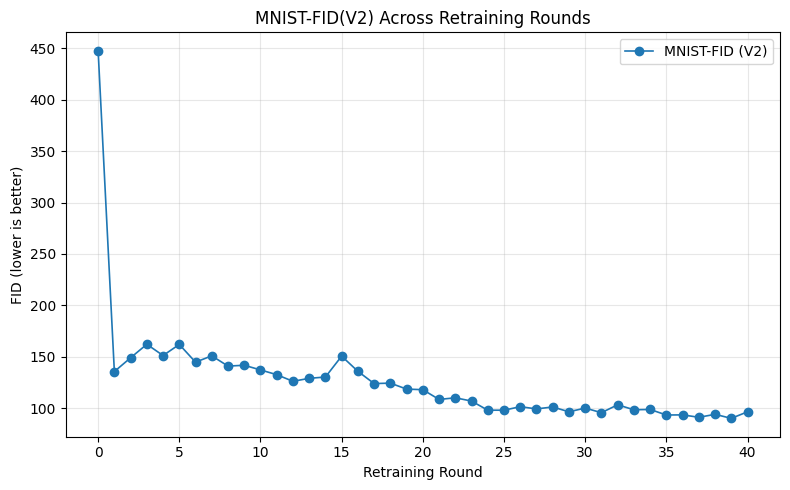

✅ Best MNIST-FID(V2): 90.0270 at round 39


In [50]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH = OUT_CSV  # 你的 CSV 文件路径

# --- 读取和清洗 ---
df = pd.read_csv(CSV_PATH)
df = df[df["mnist_fid_v2_fixed"] != "ERROR"].copy()
df["mnist_fid_v2_fixed"] = pd.to_numeric(df["mnist_fid_v2_fixed"], errors="coerce")
df = df.dropna(subset=["mnist_fid_v2_fixed"])

# --- 提取 round 编号（初始模型 = 0）---
def parse_round(name: str) -> int:
    if name == "cvae_conv_real_500.pth":
        return 0
    m = re.search(r"_r(\d+)\.pth$", name)
    return int(m.group(1)) if m else -1

df["round"] = df["model_file"].apply(parse_round)
df = df[df["round"] >= 0].sort_values("round").reset_index(drop=True)

# --- 可选平滑 ---
window = 3
df["fid_smooth"] = df["mnist_fid_v2_fixed"].rolling(window=window, center=True, min_periods=1).mean()

# --- 画图 ---
plt.figure(figsize=(8,5))
plt.plot(df["round"], df["mnist_fid_v2_fixed"], marker="o", linewidth=1.2, label="MNIST-FID (V2)")
plt.xlabel("Retraining Round")
plt.ylabel("FID (lower is better)")
plt.title("MNIST-FID(V2) Across Retraining Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_idx = df["mnist_fid_v2_fixed"].idxmin()
best_round = int(df.loc[best_idx, "round"])
best_fid = float(df.loc[best_idx, "mnist_fid_v2_fixed"])
print(f"✅ Best MNIST-FID(V2): {best_fid:.4f} at round {best_round}")


# new FID for all results

In [44]:
import os, sys, glob, csv, re, random, numpy as np, torch
import pandas as pd
from pathlib import Path

# 你的工程根
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(VAE_ROOT)
import models as models  # 需要 models.CVAE

# 特征网络（刚训练好的 v2）
CKPT_FEATURE = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt"

# 需要批量重算的实验目录（每个目录下面有 .pth）
ROOT = Path(VAE_ROOT)
SIZES = [2000, 5000, 20000]

EXPERIMENT_DIRS = []

# fixed-size（有 filter / 无 filter）
for s in SIZES:
    EXPERIMENT_DIRS.append({
        "name": f"fixed_size_{s}_filtered",
        "model_dir": ROOT / f"fixed_size_{s}/model_saved_more",
        "results_csv": ROOT / f"fixed_size_{s}/model_saved_more/mnist_fid_v2_fixed.csv",
        "tag_size": s, "filtered": True
    })
    EXPERIMENT_DIRS.append({
        "name": f"schedule_size_{s}_no_filter",
        "model_dir": ROOT / f"schedule_size_{s}_no_filter/model_saved_no_filter_more",
        "results_csv": ROOT / f"schedule_size_{s}_no_filter/model_saved_no_filter_more/mnist_fid_v2_fixed.csv",
        "tag_size": s, "filtered": False
    })

# linear increase（有 filter / 无 filter）
EXPERIMENT_DIRS.append({
    "name": "linear_filtered",
    "model_dir": ROOT / "linear_increase/model_saved_more",
    "results_csv": ROOT / "linear_increase/model_saved_more/mnist_fid_v2_fixed.csv",
    "tag_size": "linear", "filtered": True
})
EXPERIMENT_DIRS.append({
    "name": "linear_no_filter",
    "model_dir": ROOT / "schedule_size_linear_no_filter/model_saved_no_filter_more",
    "results_csv": ROOT / "schedule_size_linear_no_filter/model_saved_no_filter_more/mnist_fid_v2_fixed.csv",
    "tag_size": "linear", "filtered": False
})

# 设备 & 随机种
SEED = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("Feature ckpt:", CKPT_FEATURE)
for e in EXPERIMENT_DIRS:
    print(f"- {e['name']}: {e['model_dir']}")


DEVICE: cuda
Feature ckpt: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_feature/mnist_feature_net_v2.pt
- fixed_size_2000_filtered: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more
- schedule_size_2000_no_filter: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_2000_no_filter/model_saved_no_filter_more
- fixed_size_5000_filtered: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_5000/model_saved_more
- schedule_size_5000_no_filter: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_5000_no_filter/model_saved_no_filter_more
- fixed_size_20000_filtered: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_20000/model_saved_more
- schedule_size_20000_no_filter: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_20000_no_filter/model_saved_no_filter_more
- linear

In [45]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, TensorDataset
from scipy.linalg import sqrtm

# 和你训练时一致的特征网
class MNISTFeatureNetV2(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),   # 28 -> 14
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, 3, stride=2, padding=1),  # 7 -> 4
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(256, 10)
    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat
        return self.classifier(feat)

# 统一标准化（与训练同分布）
MEAN, STD = 0.1307, 0.3081

class NormalizeWrapper(Dataset):
    def __init__(self, base_ds, mean=MEAN, std=STD):
        self.base = base_ds; self.mean = mean; self.std = std
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        item = self.base[idx]
        x = item[0] if isinstance(item, (tuple, list)) else item
        if x.dim() == 2: x = x.unsqueeze(0)            # [H,W] -> [1,H,W]
        if x.dim() == 3 and x.shape[0] not in (1,3):   # NHWC -> NCHW 容错
            x = x.permute(2,0,1)
        x = x.float()
        if x.max() > 1.0: x = x / 255.0
        x = (x - MEAN) / STD
        return (x, item[1]) if isinstance(item, (tuple, list)) and len(item)>1 else x

@torch.no_grad()
def get_embeddings(dataset, feature_ckpt, batch_size=256, device=DEVICE):
    net = MNISTFeatureNetV2().to(device)
    net.load_state_dict(torch.load(feature_ckpt, map_location=device))
    net.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    feats = []
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        x = x.to(device).float()
        z = net(x, return_features=True)
        feats.append(z.detach().cpu())
    return torch.cat(feats, 0).numpy()

def frechet_distance(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def mnist_fid_v2_fixed(real_test_ds, synth_ds, feature_ckpt, batch_size=256, device=DEVICE):
    A = get_embeddings(NormalizeWrapper(real_test_ds),  feature_ckpt, batch_size, device)
    B = get_embeddings(NormalizeWrapper(synth_ds),      feature_ckpt, batch_size, device)
    mu1, sig1 = A.mean(0), np.cov(A, rowvar=False)
    mu2, sig2 = B.mean(0), np.cov(B, rowvar=False)
    return frechet_distance(mu1, sig1, mu2, sig2)


In [46]:
from torchvision import datasets, transforms

# 真实集（ToTensor；标准化在 wrapper 做）
real_test = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

@torch.no_grad()
def generate_images_in_batches(model, total_samples=6000, latent_dim=20,
                               num_classes=10, batch_size=10000, device=DEVICE):
    model.eval().to(device)
    images_all, labels_all = [], []
    labels_full = torch.arange(total_samples) % num_classes
    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start
        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        logits_flat = model.decoder.decode(z, y_onehot)   # (n, 784) logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()
        images_all.append(imgs); labels_all.append(y.cpu())
    return torch.cat(images_all, 0), torch.cat(labels_all, 0)

def load_cvae_model(ckpt_path: Path, latent_dim=20):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    m = models.CVAE(input_dim=784, label_dim=10, latent_dim=latent_dim, arch="conv", name=name).to(DEVICE)
    sd = torch.load(str(ckpt_path), map_location=DEVICE)
    if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]
    m.load_state_dict(sd, strict=False)
    m.eval()
    return m


In [47]:
from tqdm import tqdm

def parse_round_from_file(filename: str) -> int:
    # 初始模型当作 round=0
    if filename == "cvae_conv_real_500.pth":
        return 0
    m = re.search(r"_r(\d+)\.pth$", filename)
    return int(m.group(1)) if m else -1

def recompute_dir(experiment):
    model_dir: Path = experiment["model_dir"]
    out_csv: Path   = experiment["results_csv"]
    os.makedirs(model_dir, exist_ok=True)

    ckpts = sorted(glob.glob(str(model_dir / "*.pth")))
    print(f"[{experiment['name']}] {len(ckpts)} checkpoints in {model_dir}")

    with open(out_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["model_file", "round", "mnist_fid_v2_fixed", "num_synth", "filtered", "size"])

        for ckpt in tqdm(ckpts):
            fname = os.path.basename(ckpt)
            rnd = parse_round_from_file(fname)
            if rnd < 0:  # 跳过非标准命名
                continue
            try:
                model = load_cvae_model(ckpt)
                imgs, labels = generate_images_in_batches(model, total_samples=6000, latent_dim=20, num_classes=10, device=DEVICE)
                synth_ds = TensorDataset(imgs, labels)
                fid_val = mnist_fid_v2_fixed(real_test, synth_ds, feature_ckpt=CKPT_FEATURE, batch_size=256, device=DEVICE)
                w.writerow([fname, rnd, f"{fid_val:.6f}", len(imgs), experiment["filtered"], experiment["tag_size"]])
            except Exception as e:
                print(f"[FAIL] {fname}: {e}")
                w.writerow([fname, rnd, "ERROR", 0, experiment["filtered"], experiment["tag_size"]])

    print(f"[{experiment['name']}] ✅ saved:", out_csv)

# 跑所有目录
for exp in EXPERIMENT_DIRS:
    recompute_dir(exp)


[fixed_size_2000_filtered] 41 checkpoints in /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more


  0%|                                                                                             | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_1278516/1962034621.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relat

[fixed_size_2000_filtered] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2000/model_saved_more/mnist_fid_v2_fixed.csv
[schedule_size_2000_no_filter] 41 checkpoints in /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_2000_no_filter/model_saved_no_filter_more


100%|████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:47<00:00,  1.16s/it]


[schedule_size_2000_no_filter] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_2000_no_filter/model_saved_no_filter_more/mnist_fid_v2_fixed.csv
[fixed_size_5000_filtered] 41 checkpoints in /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_5000/model_saved_more


...

[schedule_size_20000_no_filter] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_20000_no_filter/model_saved_no_filter_more/mnist_fid_v2_fixed.csv
[linear_filtered] 41 checkpoints in /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/linear_increase/model_saved_more


100%|████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:41<00:00,  1.02s/it]


[linear_filtered] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/linear_increase/model_saved_more/mnist_fid_v2_fixed.csv
[linear_no_filter] 41 checkpoints in /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_linear_no_filter/model_saved_no_filter_more


100%|████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:41<00:00,  1.01s/it]

[linear_no_filter] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_linear_no_filter/model_saved_no_filter_more/mnist_fid_v2_fixed.csv


In [48]:
combined_rows = []
for exp in EXPERIMENT_DIRS:
    path = exp["results_csv"]
    if path.exists():
        df = pd.read_csv(path)
        df["exp_name"] = exp["name"]
        combined_rows.append(df)
    else:
        print("[skip] missing:", path)

df_all = pd.concat(combined_rows, ignore_index=True)
combined_path = ROOT / "mnist_fid_v2_fixed_all_experiments.csv"
df_all.to_csv(combined_path, index=False)
print("✅ combined saved:", combined_path)

# 预览
df_all.head()


✅ combined saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_fid_v2_fixed_all_experiments.csv


,model_file,round,mnist_fid_v2_fixed,num_synth,filtered,size,exp_name
0,cvae_conv_init500_q0.1_s2000_r1.pth,1,135.541924,6000,True,2000,fixed_size_2000_filtered
1,cvae_conv_init500_q0.1_s2000_r10.pth,10,137.146241,6000,True,2000,fixed_size_2000_filtered
2,cvae_conv_init500_q0.1_s2000_r11.pth,11,132.540076,6000,True,2000,fixed_size_2000_filtered
3,cvae_conv_init500_q0.1_s2000_r12.pth,12,126.064210,6000,True,2000,fixed_size_2000_filtered
4,cvae_conv_init500_q0.1_s2000_r13.pth,13,128.966016,6000,True,2000,fixed_size_2000_filtered


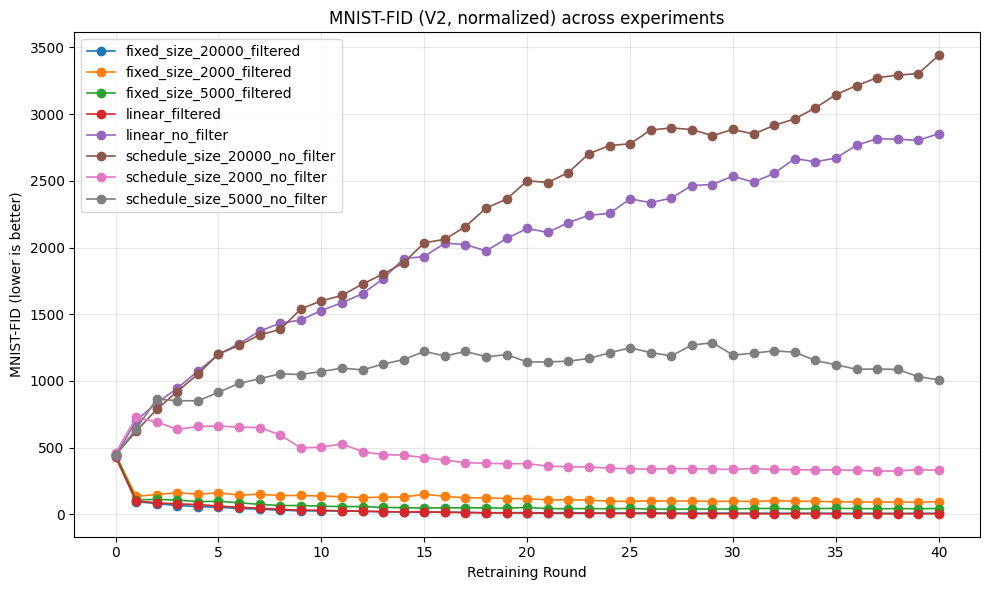

fixed_size_20000_filtered     best FID = 7.2079 at round 38
fixed_size_2000_filtered      best FID = 90.0270 at round 39
fixed_size_5000_filtered      best FID = 38.9489 at round 27
linear_filtered               best FID = 4.3369 at round 36
linear_no_filter              best FID = 436.5718 at round 0
schedule_size_20000_no_filter  best FID = 445.4072 at round 0
schedule_size_2000_no_filter  best FID = 324.5274 at round 37
schedule_size_5000_no_filter  best FID = 443.1769 at round 0


In [49]:
import matplotlib.pyplot as plt

# 只保留非 ERROR
plot_df = df_all[df_all["mnist_fid_v2_fixed"] != "ERROR"].copy()
plot_df["mnist_fid_v2_fixed"] = pd.to_numeric(plot_df["mnist_fid_v2_fixed"], errors="coerce")
plot_df = plot_df.dropna(subset=["mnist_fid_v2_fixed"])
plot_df = plot_df.sort_values(["exp_name", "round"])

plt.figure(figsize=(10,6))
for name, sub in plot_df.groupby("exp_name"):
    sub = sub.sort_values("round")
    plt.plot(sub["round"], sub["mnist_fid_v2_fixed"], marker="o", linewidth=1.2, label=name)

plt.xlabel("Retraining Round")
plt.ylabel("MNIST-FID (lower is better)")
plt.title("MNIST-FID (V2, normalized) across experiments")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 输出每个实验的最佳轮次
for name, sub in plot_df.groupby("exp_name"):
    idx = sub["mnist_fid_v2_fixed"].idxmin()
    print(f"{name:28s}  best FID = {sub.loc[idx,'mnist_fid_v2_fixed']:.4f} at round {int(sub.loc[idx,'round'])}")


In [52]:
import os
import re
import csv
import glob
from pathlib import Path
from tqdm import tqdm
import torch
from torch.utils.data import TensorDataset

# ===== 你已有的函数 / 全局变量 =====
# 请确保以下函数与变量已定义：
#   load_cvae_model(ckpt_path)
#   generate_images_in_batches(model, total_samples, latent_dim, num_classes, device)
#   mnist_fid_v2_fixed(real_test, synth_ds, feature_ckpt, batch_size, device)
#   real_test, CKPT_FEATURE, DEVICE
# ==================================

ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")

def parse_round_from_file(filename: str) -> int:
    if filename == "cvae_conv_real_500.pth":
        return 0
    m = re.search(r"_r(\d+)\.pth$", filename)
    return int(m.group(1)) if m else -1

def recompute_dir(model_dir: Path, tag_size: int, filtered=True):
    ckpts = sorted(glob.glob(str(model_dir / "*.pth")))
    if not ckpts:
        print(f"[WARN] No checkpoints in {model_dir}")
        return

    out_csv = model_dir.parent / "fid_results.csv"
    print(f"[{model_dir.parent.name}] {len(ckpts)} checkpoints -> {out_csv}")

    with open(out_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["model_file", "round", "mnist_fid_v2_fixed", "num_synth", "filtered", "size"])

        for ckpt in tqdm(ckpts):
            fname = os.path.basename(ckpt)
            rnd = parse_round_from_file(fname)
            if rnd < 0:
                continue
            try:
                model = load_cvae_model(ckpt)
                imgs, labels = generate_images_in_batches(
                    model,
                    total_samples=6000,
                    latent_dim=20,
                    num_classes=10,
                    device=DEVICE,
                )
                synth_ds = TensorDataset(imgs, labels)
                fid_val = mnist_fid_v2_fixed(
                    real_test,
                    synth_ds,
                    feature_ckpt=CKPT_FEATURE,
                    batch_size=256,
                    device=DEVICE,
                )
                w.writerow([fname, rnd, f"{fid_val:.6f}", len(imgs), filtered, tag_size])
            except Exception as e:
                print(f"[FAIL] {fname}: {e}")
                w.writerow([fname, rnd, "ERROR", 0, filtered, tag_size])

    print(f"[{model_dir.parent.name}] ✅ saved: {out_csv}")


# ===== 主程序：遍历 dic_* 和 fixed_size_20000 =====
for entry in ROOT.iterdir():
    if not entry.is_dir():
        continue

    name = entry.name
    # 只处理 dic_* 和 fixed_size_20000
    if not (name.startswith("dic_") or name == "fixed_size_20000"):
        continue

    # 解析样本量
    if name.startswith("dic_"):
        m = re.search(r"dic_(\d+)", name)
        tag_size = int(m.group(1)) if m else -1
    elif name == "fixed_size_20000":
        tag_size = 60000
    else:
        tag_size = -1

    model_subdir = entry / "model_saved_more"
    if not model_subdir.exists():
        print(f"[SKIP] No model_saved_more under {entry}")
        continue

    recompute_dir(model_subdir, tag_size=tag_size, filtered=True)


[dic_10000] 41 checkpoints -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_10000/fid_results.csv


  0%|                                                                                             | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_1278516/1962034621.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relat

[dic_10000] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_10000/fid_results.csv
[fixed_size_20000] 41 checkpoints -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_20000/fid_results.csv


100%|████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:46<00:00,  1.12s/it]


[fixed_size_20000] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_20000/fid_results.csv
[dic_40000] 41 checkpoints -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_40000/fid_results.csv


...

[dic_20000] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_20000/fid_results.csv
[dic_500] 41 checkpoints -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_500/fid_results.csv


100%|████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:46<00:00,  1.14s/it]


[dic_500] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_500/fid_results.csv
[dic_5000] 41 checkpoints -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_5000/fid_results.csv


100%|████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:46<00:00,  1.14s/it]

[dic_5000] ✅ saved: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/dic_5000/fid_results.csv


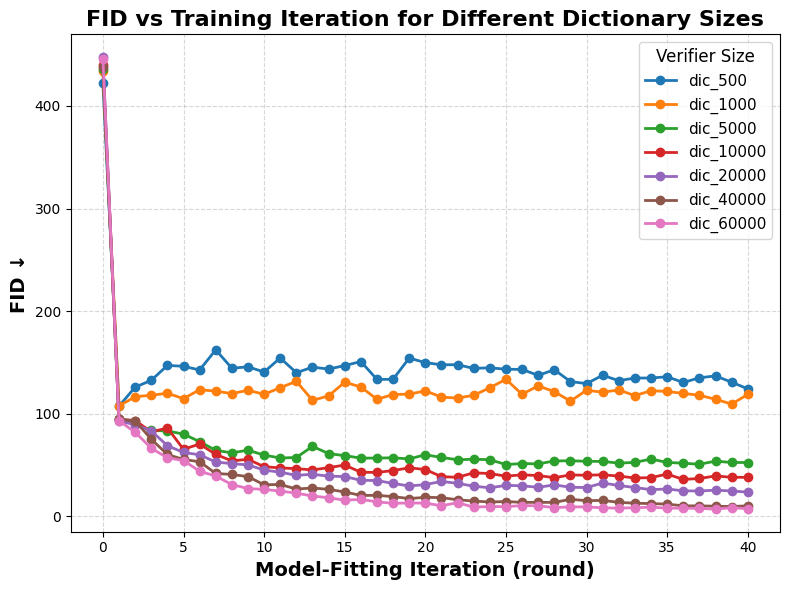

In [53]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")

# --- gather all fid_results.csv ---
rows = []
for sub in ROOT.iterdir():
    if not sub.is_dir():
        continue
    name = sub.name
    if not (name.startswith("dic_") or name == "fixed_size_20000"):
        continue

    csv_path = sub / "fid_results.csv"
    if not csv_path.exists():
        print(f"[WARN] missing: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    if "mnist_fid_v2_fixed" not in df.columns:
        print(f"[WARN] missing fid col: {csv_path}")
        continue

    # parse size
    if name.startswith("dic_"):
        m = re.search(r"dic_(\d+)", name)
        verifier_size = int(m.group(1)) if m else None
    elif name == "fixed_size_20000":
        verifier_size = 60000  # treat as dic_60000

    df["verifier_size"] = verifier_size
    rows.append(df)

df_all = pd.concat(rows, ignore_index=True)
df_all["mnist_fid_v2_fixed"] = pd.to_numeric(df_all["mnist_fid_v2_fixed"], errors="coerce")
df_all = df_all.dropna(subset=["mnist_fid_v2_fixed"])

# --- plot ---
plt.figure(figsize=(8,6))
for size, sub in sorted(df_all.groupby("verifier_size"), key=lambda x: x[0]):
    sub = sub.sort_values("round")
    plt.plot(sub["round"], sub["mnist_fid_v2_fixed"], marker="o", lw=2, label=f"dic_{size}")

plt.xlabel("Model-Fitting Iteration (round)", fontsize=14, fontweight="bold")
plt.ylabel("FID ↓", fontsize=14, fontweight="bold")
plt.title("FID vs Training Iteration for Different Dictionary Sizes", fontsize=16, fontweight="bold")
plt.legend(title="Verifier Size", fontsize=11, title_fontsize=12)
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()
